<span style="color:#44f;font-weight:bold;">Codes for CNS2025: Lecture 16</span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Tuning surface

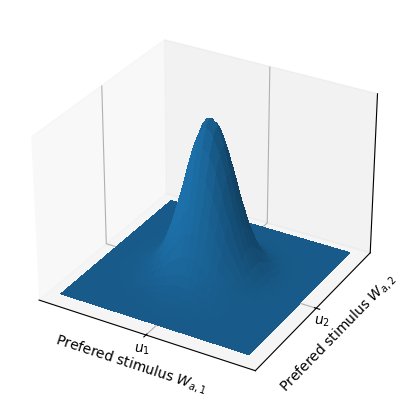

In [2]:
f = plt.figure(figsize=(5,5))
a = f.add_subplot(projection='3d')
x,y = np.meshgrid(np.arange(-3,3,0.1),np.arange(-3,3,0.1))
a.plot_surface(x,y,np.exp(-x**2-y**2),linewidth=0,antialiased=False)
a.set_xticks([0])
a.tick_params(axis='x',which='major',pad=-4)
a.tick_params(axis='y',which='major',pad=-4)
a.set_xticklabels(['$u_1$'])
a.set_xlabel('Prefered stimulus $W_{a,1}$',labelpad=-6)
a.set_yticks([0])
a.set_yticklabels(['$u_2$'])
a.set_ylabel('Prefered stimulus $W_{a,2}$',labelpad=-6)
a.set_zticks([])
plt.show()

## Elastic net


### Reference
Erwin, E., K. Obermayer, and K. Schulten. “Models of Orientation and Ocular Dominance Columns in the Visual Cortex: A Critical Comparison.” Neural Computation 7, no. 3 (May 1, 1995): 425–68. https://doi.org/10.1162/neco.1995.7.3.425. \
PDF: http://www-s.ks.uiuc.edu/Publications/Papers/PDF/ERWI95A/ERWI95A.pdf

In [3]:
# Parameters
qmax = 61.44
zmax = 46.08
sigma = 2.771
alpha = 0.4
beta = 0.0001
T = 2000000 # Number of iterations
L = 128 # Lateral length
N = 256 # Linear size

In [4]:
def dxy(x1,x2): # Periodic spatial distance
    return L/2-np.abs(L/2-np.abs(x1-x2))

def d2(v,phi): # Distance square in feature space
    [vx,vy,vqs,vqc,vz] = v
    [xs,ys,qsn,qcs,zs] = phi
    return dxy(xs,vx)**2+dxy(ys,vy)**2+(qsn-vqs)**2+(qcs-vqc)**2+(zs-vz)**2

In [5]:
from itertools import product

In [6]:
def phi_p(sm=0): # Get phase
    ave = phi
    for i in range(sm): # Smoothing
        ave = np.mean([np.roll(ave,d,axis=a) for d,a in product([1,-1],[1,2])],axis=0)
    return np.arctan2(ave[2],ave[3])

def phi_q(sm=0): # Get amplitude
    ave = phi
    for i in range(sm): # Smoothing
        ave = np.mean([np.roll(ave,d,axis=a) for d,a in product([1,-1],[1,2])],axis=0)
    return np.sqrt(ave[2]*ave[2]+ave[3]*ave[3])

def phi_z(sm=0): # Get dominance
    ave = phi
    for i in range(sm): # Smoothing
        ave = np.mean([np.roll(ave,d,axis=a) for d,a in product([1,-1],[1,2])],axis=0)
    return ave[-1]

In [7]:
def hen(v,phi): # Competition activity variable
    h = np.exp(-d2(v,phi)/(2*sigma**2))
    return h/h.sum()

In [8]:
def gen_v(): # Generate a random sample
    vx = rng.uniform(0,L)
    vy = rng.uniform(0,L)
    vq = rng.uniform(0,qmax)
    vz = rng.uniform(-zmax,zmax)
    vp = rng.uniform(0,np.pi)
    return np.array([vx,vy,vq*np.sin(2*vp),vq*np.cos(2*vp),vz])

In [9]:
# Initial values
def init_state():
    # Position
    xs = np.outer(np.arange(N)*L/N,np.ones(N))
    ys = np.outer(np.ones(N),np.arange(N)*L/N)
    # Orientation
    qs = 0.01*qmax*np.ones((N,N))
    ps = rng.uniform(0,np.pi,(N,N))
    qsn = qs*np.sin(2*ps)
    qcs = qs*np.cos(2*ps)
    # Ocular dominance
    zs = rng.normal(size=(N,N))
    return np.array([xs,ys,qsn,qcs,zs])
rng = np.random.default_rng(123)
phi = init_state()
cnt = 0

In [10]:
from os.path import exists

In [11]:
data_file = 'lec16-data.npz'
if exists(data_file):
    with np.load(data_file,allow_pickle=True) as f:
        phi = f['phi']
else:
    # Elastic net iteration
    while cnt<T:
        v = gen_v() # Random pattern
        h = hen(v,phi)
        phi += alpha*h*(v[:,None,None]-phi)+beta*(np.sum([
            np.roll(phi,d,axis=a) # Neighborhood
            for d,a in product([1,-1],[1,2])
        ],axis=0)-4*phi)
        cnt += 1
        if cnt%100==0:
            print(f'\r{cnt//100}/{T//100}',end='')
    print(f'\rDone! {cnt=}   ')
    np.savez(data_file,phi=phi)

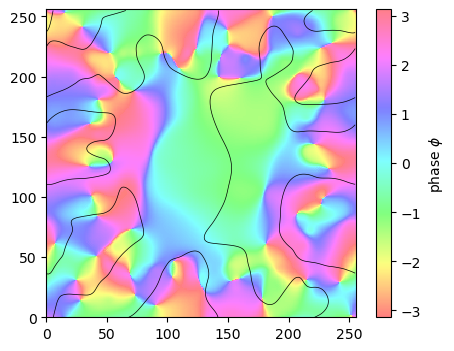

In [12]:
plt.figure(figsize=(5,4))
plt.pcolormesh(phi_p(8),cmap='hsv',alpha=0.5)
plt.colorbar(label=r'phase $\phi$')
plt.contour(phi_z(8),[0],colors=['black'],linewidths=0.5)
plt.show()

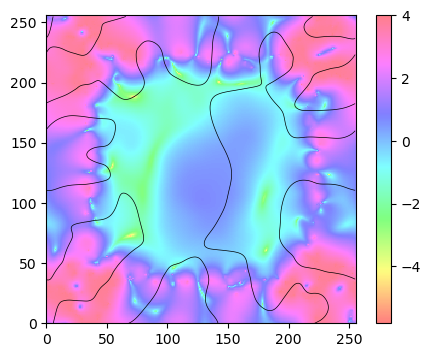

In [13]:
plt.figure(figsize=(5,4))
plt.pcolormesh(np.log(phi_q()),cmap='hsv',alpha=0.5)
plt.colorbar()
plt.contour(phi_z(8),[0],colors=['black'],linewidths=0.5)
plt.show()

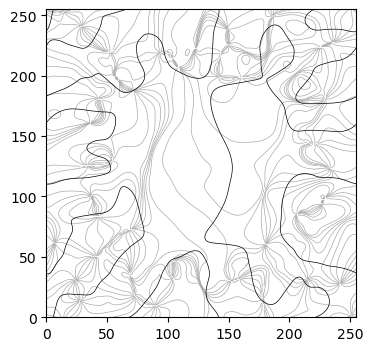

In [14]:
plt.figure(figsize=(4,4))
p = phi_p(8)
p[p<0] = np.nan # mask out half
plt.contour(p,levels=8,colors=['#aaa'],linewidths=0.5)
p = phi_p(8)+np.pi
p[p>np.pi] = np.nan # mask out the other half
plt.contour(p,levels=8,colors=['#aaa'],linewidths=0.5)
plt.contour(phi_z(8),[0],colors=['black'],linewidths=0.5)
plt.show()

## Supervised learning

In [15]:
rng = np.random.default_rng(123)
th1 = -0.7
th2 = 1.0
[x1,y1] = (
    rng.multivariate_normal([0,0],[[2,0],[0,4]],16)
    @ np.array([[np.cos(th1),np.sin(th1)],[-np.sin(th1),np.cos(th1)]])
    + [6,8]
).T
[x2,y2] = (
    rng.multivariate_normal([0,0],[[6,0],[0,3]],20)
    @ np.array([[np.cos(th2),np.sin(th2)],[-np.sin(th2),np.cos(th2)]])
    + [8,2]
).T

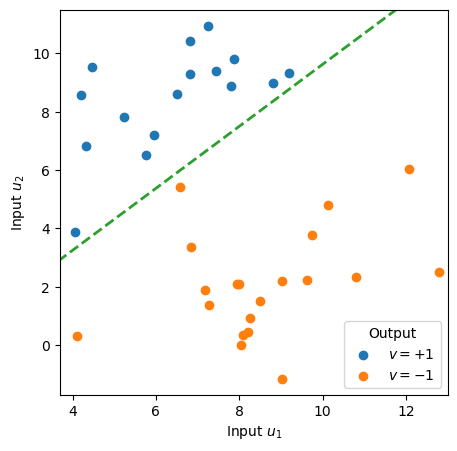

In [16]:
plt.figure(figsize=(5,5))
plt.scatter(x1,y1,label=r'$v=+1$')
plt.scatter(x2,y2,label=r'$v=-1$')
plt.plot([0,16],[-1,16],'--',color='C2',lw=2)
plt.xlim([3.7,13])
plt.ylim([-1.7,11.5])
plt.xlabel('Input $u_1$')
plt.ylabel('Input $u_2$')
plt.legend(title='Output')
plt.show()

## Error of perceptron with random data

In [17]:
from scipy.stats import norm

In [18]:
gau = norm.pdf(0,1)
x = np.linspace(-3,3,257)

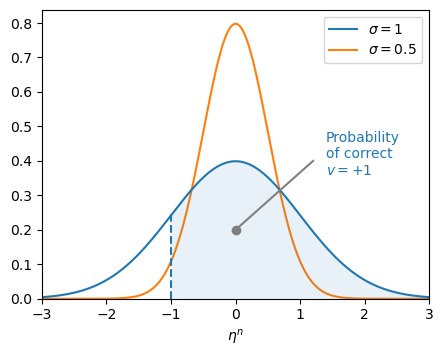

In [19]:
plt.figure(figsize=(5,3.75))
y = norm(0,1).pdf(x)
plt.plot(x,y,label=r'$\sigma=1$')
w = x>-1
plt.fill_between(x[w],0,y[w],alpha=.1)
plt.vlines(-1,0,y[x>-1][0],ls='--')
y = norm(0,.5).pdf(x)
plt.plot(x,y,label=r'$\sigma=0.5$',zorder=-1)
plt.xlim(-3,3)
plt.ylim(0,)
plt.xlabel(r'$\eta^n$')
plt.plot([0,1.2],[0.2,0.4],color='gray')
plt.scatter(0,0.2,c='gray')
plt.text(1.4,0.36,'Probability\nof correct\n$v=+1$',color='C0')
plt.legend()
plt.show()

## Probaility of correction prediction
\begin{equation*}
    P[\mathrm{correct}] = \sqrt{\frac{N_u}{2\pi(N_S-1)}}\int_{-\infty}^1 d\eta\,\exp\left(-\frac{N_u \eta^2}{2(N_S-1)}\right)
\end{equation*}

Integral of Gaussian → Error function
$$\operatorname{erf} z={\frac {2}{\sqrt {\pi }}}\int _{0}^{z}e^{-t^{2}}\,\mathrm {d} t$$


Let $$ t = \sqrt{\frac{N_u}{2(N_S-1)}}\eta $$

\begin{align*}
    P[\mathrm{correct}] & = \frac{1}{\sqrt{\pi}} \int_{-\infty}^{\sqrt{\frac{N_u}{2(N_S-1)}}} dt\,\exp\left(-t^2\right) \\
    & = \frac{1}{2}\left(1+\frac{2}{\sqrt{\pi}} \int_0^{\sqrt{\frac{N_u}{2(N_S-1)}}} dt\,e^{-t^2}\right) \\
    & = \frac{1}{2}\left(1+\operatorname{erf}\left(\sqrt{\frac{N_u}{2(N_S-1)}}\right)\right)
\end{align*}

In [20]:
from scipy.special import erf

In [21]:
v = np.arange(0,10,2**-10) # $N_u/(N_S-1)$
pc = (1+erf(np.sqrt(v/2)))/2

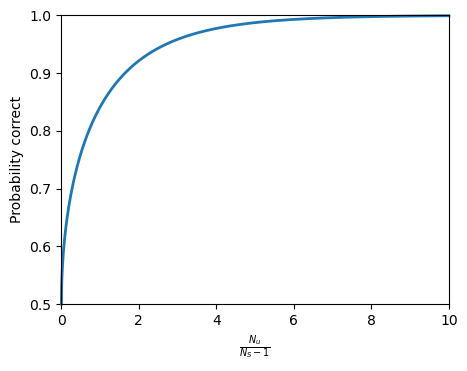

In [22]:
plt.figure(figsize=(5,3.75))
plt.plot(v,pc,lw=2,clip_on=False)
plt.xlim(0,10)
plt.ylim(.5,1)
plt.xlabel(r'$\frac{N_u}{N_S-1}$')
plt.ylabel('Probability correct')
plt.show()

## Function approximation

In [23]:
def fun(s,sb): # Basis function
    return np.exp(-(s-sb)**2/2)

In [24]:
def tgt(s): # Target function to be learned
    return np.cos(s*2*np.pi/10)

In [25]:
sbs = np.arange(-10,11,2) # Prefered stimuli for neurons
ew = 1.0 # Learning rate

In [26]:
ss = np.linspace(-10,10,257) # Drawing points

In [27]:
def init(seed=123): # Initialize
    global rng
    global wts
    rng = np.random.default_rng(seed)
    wts = rng.uniform(-1,1,len(sbs))

In [28]:
def train(n=1): # Train for n steps
    global wts
    for i in range(n):
        s = rng.uniform(-10,10)
        wts += ew*(tgt(s)-wts@fun(s,sbs))*fun(s,sbs)

In [29]:
def get_rs(ss): # Calculate output
    return fun(ss[:,None],sbs[None,:])@wts

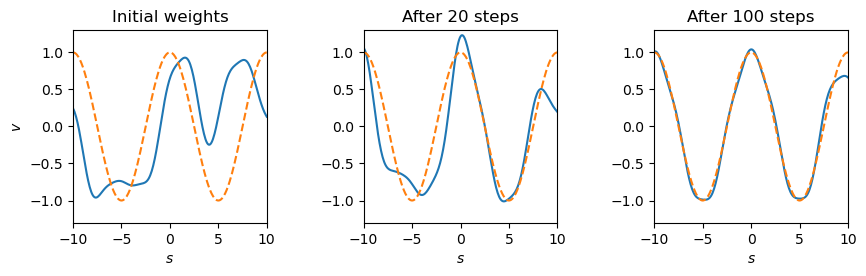

In [30]:
f,aa = plt.subplots(1,3,figsize=(10,2.5))
f.subplots_adjust(wspace=0.5)
init()
for n,a,t in zip([0,20,80],aa,['Initial weights','After 20 steps','After 100 steps']):
    train(n)
    a.plot(ss,get_rs(ss))
    a.plot(ss,tgt(ss),'--')
    a.set_xlim(-10,10)
    a.set_ylim(-1.3,1.3)
    a.set_xlabel('$s$')
    a.set_title(t)
aa[0].set_ylabel('$v$')
plt.show()

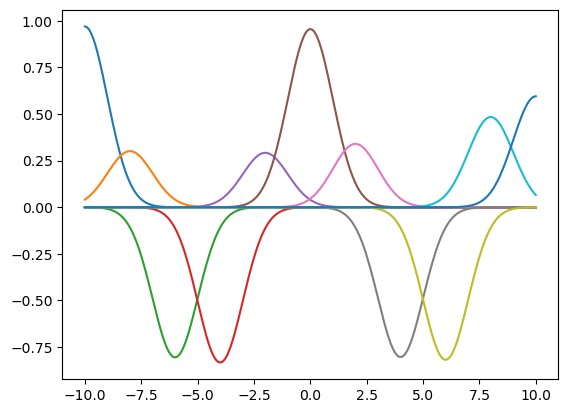

In [31]:
# Show the components of the outputs for all ss
plt.plot(ss,fun(ss[:,None],sbs[None,:])*wts)
plt.show()

In [32]:
def triangle(s):
    return 5+s*(s<0)-s/2

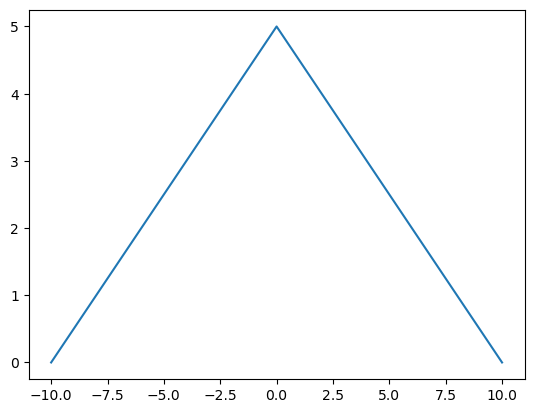

In [33]:
plt.plot(ss,triangle(ss))
plt.show()

<hr>
<address style="color:#44f;font-style:italic;font-weight:bold;"><a href="https://cc.tir.tw/wk/2025cns">CNS2025</a></address>